# CAPM (Capital asset pricing model)
$$
\begin{align*}
E(R_i ) = R_f + \beta_i \big(E(R_M)-R_f   \big)
\end{align*}
$$

where 
- $E(R_i)=$(expected return on asset i), 
- $R_f=$(risk free rate), 
- $E(R_M)=$(expected return on market return, such as, KOSPI or S&P500).

\begin{align*}
\beta_i = \frac{cov(R_i, R_M)}{var(R_M)}
\end{align*}

## Interpretation of CAPM

**I assume that portfolio is composed of one asset and $R_f=0$**

\begin{align*}
R_i  = -0.041 + 0.952^{**} R_M 
\end{align*}

- How to measure whether a fund manager add value beyond investing in the index? 
   Or how well did the fund manager do compared to  
   benchmark?    $\Rightarrow$     **CAPM alpha**

- CAPM alpha shows return not captured by the market
  - In empirics CAPM alpha is -0.041 and statistically insignificant (that is not meaningful in natural language) 
  - If alpha is statistically significant, then we cay say that the manager subtracts decremental return of -4.1% per day beyond the benchmark

-  CAPM beta is a measure how sensitive the portfolio return to overall market
-  It is called “systematic risk” or “market risk”
   - undiversifiable risk
   - risk premium 
-  If the market goes up by 1%, then portfolio return up by 0.95%
  -  defensive(countercyclical) stock: 𝛽≤1
  -  pro-cyclical stock: 𝛽≥1


## IS CAPM sensible?

-  Investors are compensated for taking necessary risk, but not for unnecessary risk
    - Market risk is inescapable and borne by aggregate investors
    - However, residual risk is SELF-IMPOSED and is avoidable risk. 
    -  On average non-zero  residual risks come from overweighting stock exactly matched by other investor(s) taking opposite position: <br>
     ⇒  Greater Fool Theory
-  So, investors who don’t have superior information should hold the market portfolio
        ⇒ Passive Investing Strategy



## CAPM's Contribution
-  Empirical results supporting the model is limited or very scarce, however, market participants are using for remuneration or world portfolio composition or consulting for new industry
-  Identify systematic and non-system risk with very simple model
-  Identify risk factor(s) $\beta_i$



## CAPM's Limitation

-  what is market portfolio? 
  -  S&P500, NASDAQ, World Porfolio 
-  Roll’s critique: estimated $\beta_i$ cannot predict future returns
- Three factor models by Fama and French: along with market return, price-to-book ratio, size of capitalization (small cap) do matter explaining excess return



## Market neutral Strategy

- If a fund manager believe the following CAPM estimation results and confident about it, then she/he will be facing negative alpha?
\begin{align*}
(R_p - R_f)  = 0.4 + 0.9^{**} (R_M - R_f)
\end{align*}

- How to neutralized it?  
    - Bodie, Kane, and Marcus (2005, sec 10.4)    <br>
    - construct tracking portfolio matching systematic component of $R_p$:  
    \begin{align*}
      R_{TP} &= \beta R_M + (1-\beta) R_f \\
      R_{TP} &= 0.9R_M + 0.1R_f \\
      \big( R_{TP} - R_f  \big) &= 0.9 \big(R_M - R_f   \big)
    \end{align*}
  <br> 
    - Go long with $R_p$ and short with $R_{TP}$ ($R_p - R_{TP})$. Then manager earn fixed 4% return  

In [1]:
import sys
import pandas as pd
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt 
plt.style.use('seaborn')

import yfinance as yf 

In [2]:
import seaborn as sns 

In [3]:
aapl = yf.download('AAPL')
snp = yf.download('^GSPC')

df = pd.DataFrame().assign(aapl=aapl.Close, snp=snp.Close)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [4]:
ret = df.pct_change().dropna()
ret *= 100

<AxesSubplot:xlabel='Date'>

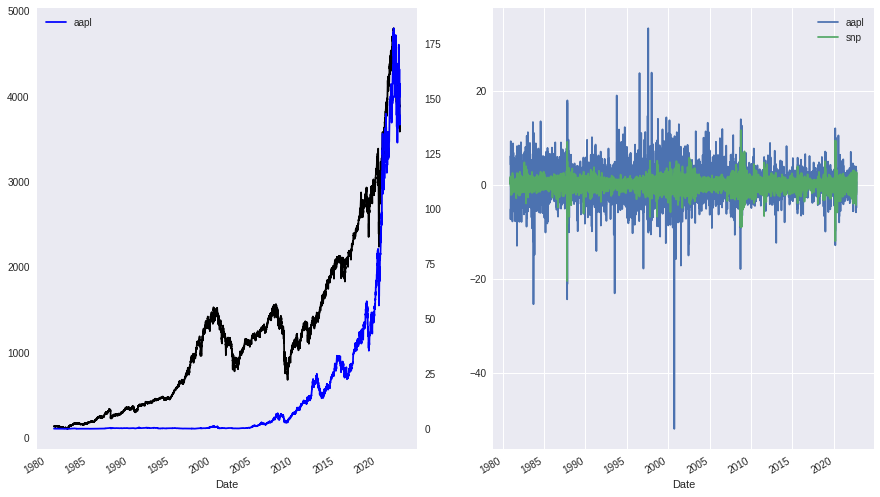

In [5]:
fig = plt.figure(figsize=(15,9))
ax1 = fig.add_subplot(121)
df.snp.plot(ax=ax1, c='k')
ax1.grid(False)
ax2 = ax1.twinx()
df.aapl.plot(ax=ax2, c='b', label='aapl')
ax2.grid(False)
plt.legend()
ax3 = fig.add_subplot(122)
ret.plot(ax=ax3)

/home/chung/miniconda3/envs/automl.0.5/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='snp', ylabel='aapl'>

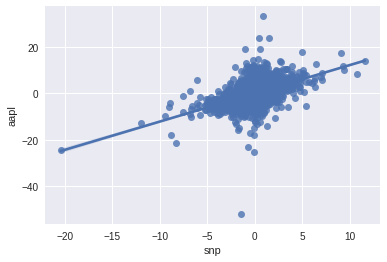

In [6]:
# scatter plot

#plt.scatter(ret.snp, ret.aapl)
sns.regplot("snp", "aapl", data=ret)

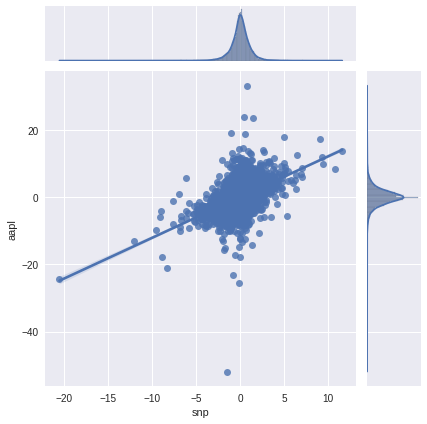

In [7]:
import warnings 
warnings.filterwarnings('ignore')

sns.jointplot(ret['snp'], ret['aapl'], kind='reg', )

In [8]:
from statsmodels.formula.api import ols 
model_ols = ols('aapl~1+snp', data=ret).fit()
model_ols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   aapl   R-squared:                       0.238
Model:                            OLS   Adj. R-squared:                  0.238
Method:                 Least Squares   F-statistic:                     3288.
Date:                Tue, 04 Oct 2022   Prob (F-statistic):               0.00
Time:                        15:05:00   Log-Likelihood:                -24489.
No. Observations:               10540   AIC:                         4.898e+04
Df Residuals:                   10538   BIC:                         4.900e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0608      0.024      2.523      0.012       0.014       0.108
snp            1.2159      0.021     57.340      0.000       1.174       1.257
==============================================================================
Omnibus:                     3079.948   Durbin-Watson:                   1.914
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           291038.884
Skew:                          -0.382   Prob(JB):                         0.00
Kurtosis:                      28.732   Cond. No.                         1.14
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [9]:
retMonthly = ret.asfreq('m', method='bfill')

In [10]:
from statsmodels.formula.api import ols 
monthly_ols = ols('aapl~ 1+snp', data=retMonthly).fit()
monthly_ols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   aapl   R-squared:                       0.274
Model:                            OLS   Adj. R-squared:                  0.273
Method:                 Least Squares   F-statistic:                     188.9
Date:                Tue, 04 Oct 2022   Prob (F-statistic):           1.07e-36
Time:                        15:05:23   Log-Likelihood:                -1095.6
No. Observations:                 502   AIC:                             2195.
Df Residuals:                     500   BIC:                             2204.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0889      0.096      0.925      0.355      -0.100       0.278
snp            1.1291      0.082     13.745      0.000       0.968       1.291
==============================================================================
Omnibus:                       83.505   Durbin-Watson:                   1.998
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              297.868
Skew:                           0.725   Prob(JB):                     2.08e-65
Kurtosis:                       6.484   Cond. No.                         1.18
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [11]:
# monthly rolling regression

beta  = []
alpha  = []
lookback = 60

for i in range(len(retMonthly)-lookback):
    reg = ols('aapl~1+snp', data=retMonthly[i:i+lookback]).fit()
    beta.append(reg.params[1])
    alpha.append(reg.params[0])

In [ ]:
factors = pd.DataFrame().assign(beta=beta, alpha=alpha)
factors.index = retMonthly.index[lookback:]

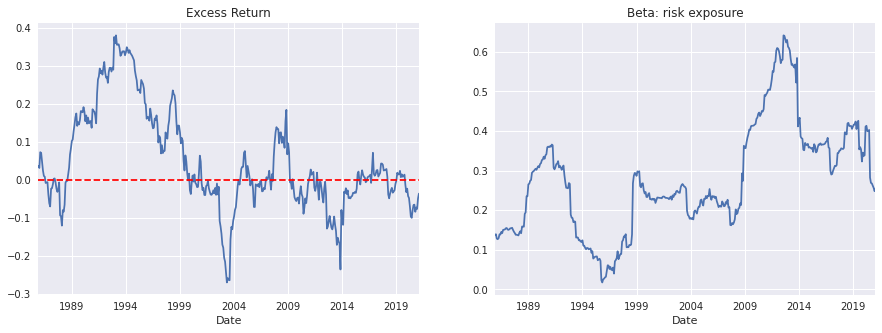

In [ ]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(15,5))
factors.alpha.plot(ax=ax1)
ax1.set_title('Excess Return')
ax1.axhline(0, color='red', ls='--')
factors.beta.plot(ax=ax2)
ax2.set_title('Beta: risk exposure');